In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [3]:
train_test_df = pd.read_csv('./../datasets/csi_bli/csi_bli/csi_bli_train_test_split.csv')
auprc_baseline = train_test_df['Signal Normalised to -ve Control_binarized'].sum()/len(train_test_df)


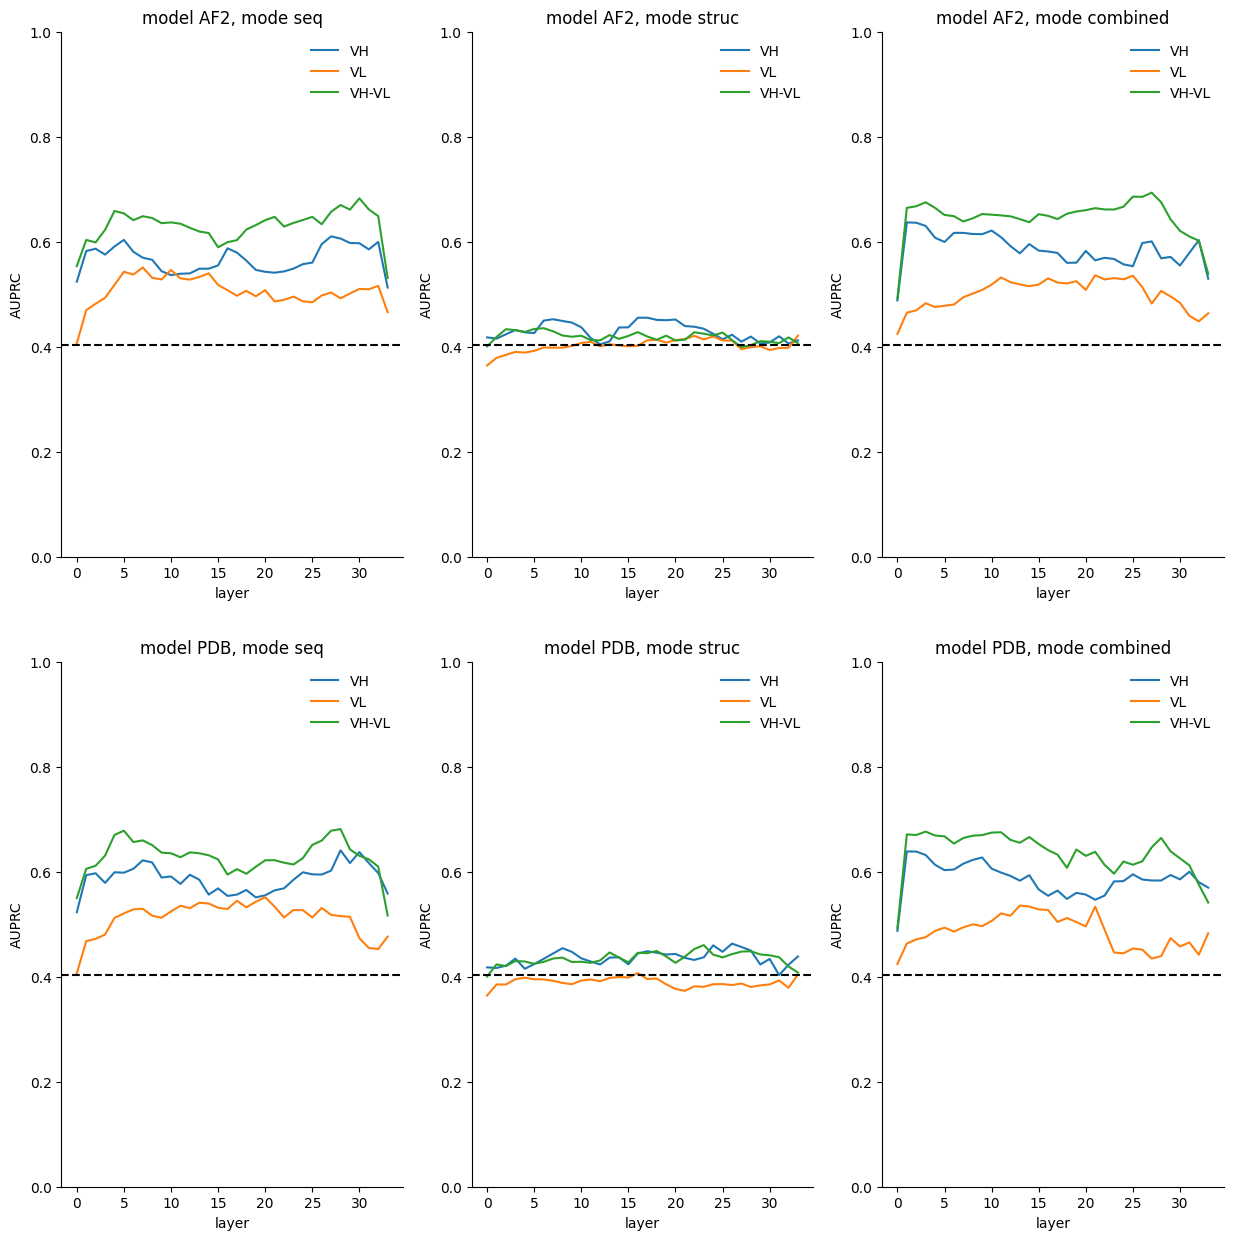

In [ ]:
#### AUPRC
chains = ['VH', 'VL', 'VH-VL']
modes = ['seq', 'struc', 'combined']
models = ['AF2', 'PDB']
metric = 'auprc'
results_path = './results/SaProt//'

fig, axs = plt.subplots(
    nrows=len(models),
    ncols=len(modes),
    figsize=(5*len(chains), 5*len(modes))
)

for idx, model in enumerate(models):
    for jdx, mode in enumerate(modes):
        plot_df = pd.concat(
            [pd.read_csv(f"{results_path}/{mode}/linear_probe_result_{model}_{chain}.csv") for chain in chains]
        )
        b = sns.lineplot(
            data=plot_df,
            x='layer',
            y=metric,
            hue='chain',
            ax=axs[idx][jdx]
        )
        b.axhline(auprc_baseline, color='black', linestyle='--')
        b.set(ylim=(0,1))
        b.legend(frameon=False)
        b.set_ylabel(metric.upper())
        b.set_title(f"model {model}, mode {mode}")



sns.despine(top=True, right=True)

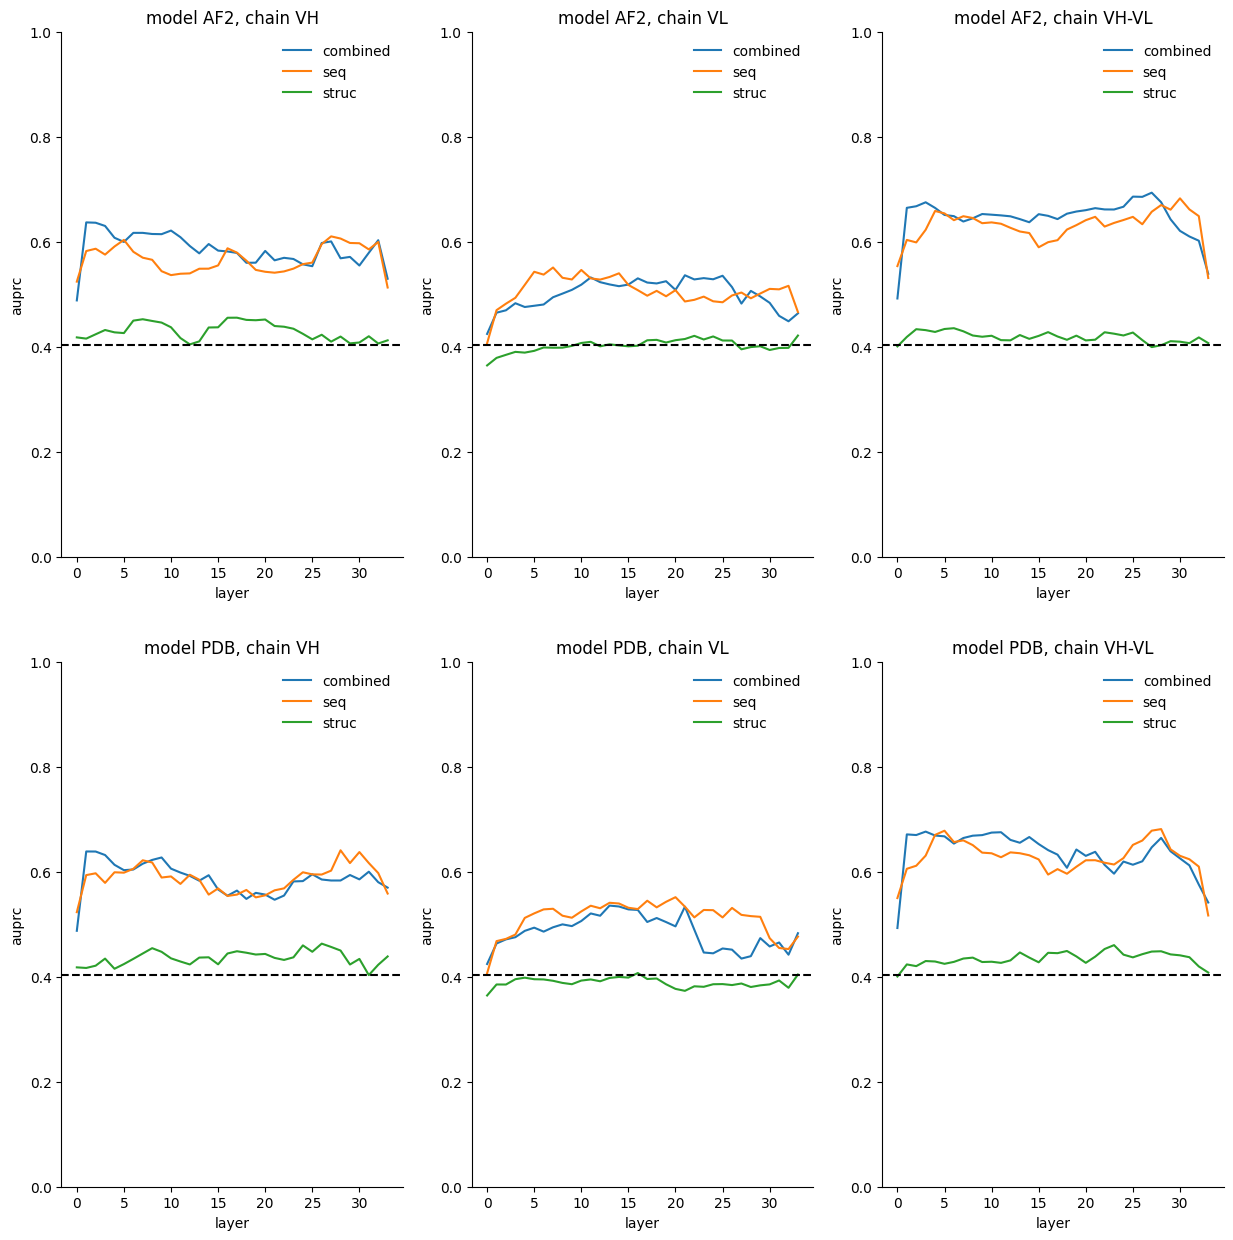

In [19]:
#### AUPRC
chains = ['VH', 'VL', 'VH-VL']
modes = ['seq', 'struc', 'combined']
models = ['AF2', 'PDB']

results_path = './results/SaProt//'

fig, axs = plt.subplots(
    nrows=len(models),
    ncols=len(modes),
    figsize=(5*len(chains), 5*len(modes))
)

for idx, model in enumerate(models):
    for jdx, chain in enumerate(chains):

        plot_df = []
        for mode in modes:
            df_ = pd.read_csv(f"{results_path}/{mode}/linear_probe_result_{model}_{chain}.csv")
            df_['modes'] = [mode]*len(df_)
            plot_df = plot_df + [df_]
        plot_df = pd.concat(plot_df).sort_values('modes')

        b = sns.lineplot(
            data=plot_df,
            x='layer',
            y='auprc',
            hue='modes',
            ax=axs[idx][jdx]
        )
        b.axhline(auprc_baseline, color='black', linestyle='--')
        b.set(ylim=(0,1))
        b.legend(frameon=False)
        b.set_title(f"model {model}, chain {chain}")



sns.despine(top=True, right=True)

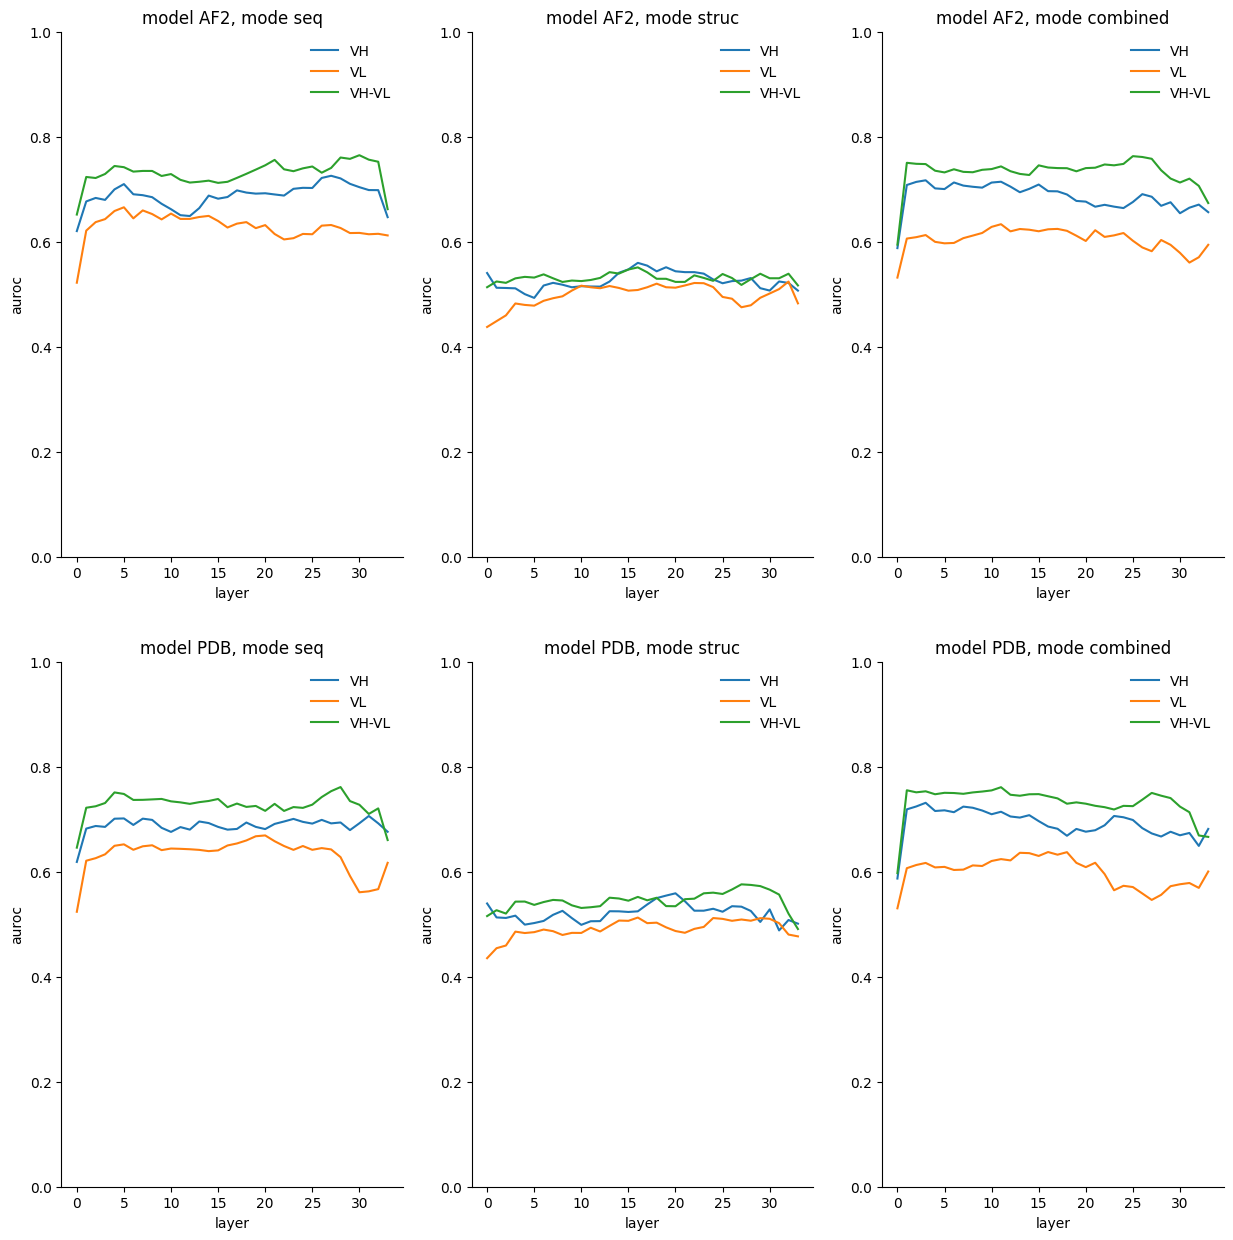

In [12]:
##### AUROC 
chains = ['VH', 'VL', 'VH-VL']
modes = ['seq', 'struc', 'combined']
models = ['AF2', 'PDB']

results_path = './results/SaProt//'

fig, axs = plt.subplots(
    nrows=len(models),
    ncols=len(modes),
    figsize=(5*len(chains), 5*len(modes))
)

for idx, model in enumerate(models):
    for jdx, mode in enumerate(modes):
        plot_df = pd.concat(
            [pd.read_csv(f"{results_path}/{mode}/linear_probe_result_{model}_{chain}.csv") for chain in chains]
        )
        b = sns.lineplot(
            data=plot_df,
            x='layer',
            y='auroc',
            hue='chain',
            ax=axs[idx][jdx]
        )
        b.set(ylim=(0,1))
        b.legend(frameon=False)
        b.set_title(f"model {model}, mode {mode}")



sns.despine(top=True, right=True)